# Limites de bruit en sortie DRE

## Documents d'entrée:
* XIFU-RD-13200-00812-CNES v2.0
* XIFU-RD-10000-00871-CNES v1.0

## Paramètres error signal:

XIFU-DRE-R-250: A first order low pass filter shall be implemented after the input stage and before the ADC conversion. The 3 dB cut-off frequency is 20 MHz

XIFU-DRE-R-301: The white noise shall be less than 25 nV / rtHz referred to the WFEE interface input

XIFU-DRE-R-0280: The readout of the analog error signal shall have a 1/f noise amplitude < 4 µV / rtHz at 1 Hz

## Paramètres MUX SQUID FB:

XIFU-DRE-R-0410: The MUX SQUID feedback signal shall have a broadband noise less than 20 nV / rtHz

XIFU-DRE-R-0420: The MUX SQUID feedback signal shall have a 1/f noise amplitude < 700 nV / rtHz at 1 Hz.

XIFU-IFDRE-R-0040: DRE output bandwidth -3dB 60MHz


## Paramètres AMP SQUID OFCO:

XIFU-DRE-R-0540: The AMP SQUID offset signal shall have an input-referred noise level < 15 nV / rtHz.

XIFU-DRE-R-0550: The AMP SQUID offset signal shall have a 1/f noise amplitude < 2.7 µV / rtHz at 1 Hz.

XIFU-IFDRE-R-0040: DRE output bandwidth -3dB 60MHz

## Fonction d'aliasing:

In [10]:
def export_2vectors_to_file(x, y, filename):
    if len(x) != len(y):
        raise ValueError("The vectors have different sizes")

    # Utilise builtins.open si vous êtes dans IPython
    import builtins
    with builtins.open(filename, 'w+') as file:
        for i in range(len(x)):
            file.write('{0:}  {1:}\n'.format(x[i], y[i]))


In [11]:
import types


def aliasing(noise_func, analog_bw, fs, n):
    if not isinstance(noise_func, types.FunctionType):
        print("noise_func n'est pas une fonction")
        return

    f_nyq = fs / 2

    if analog_bw < f_nyq:
        print("La bande analogique est inférieure à la fréquence de Nyquist")
        return

    #freqs numériques
    f_num = np.unique(np.round(np.logspace(0, np.ceil(np.log10(f_nyq)), n)))  #arrondi au Hz et unique
    f_num = f_num[f_num < f_nyq]
    f_num = np.append(f_num, f_nyq)  #on est sûr de pas dépasser la fréquence de nyquist et d'avoir un point dessus
    #on ajoute les repliement "impaire" Fs-f
    f_num = np.unique(np.sort(np.append(f_num, fs - f_num)))

    # Fréquence analogique (Hz)
    # ce sont les fréquences numériques périodisée sur toute la bande
    k_alias_max = np.ceil(analog_bw / fs)

    # Construction des alias
    k_alias = np.arange(0, k_alias_max + 1)[:, None]  # vecteur colonne
    f_analogique = f_num + k_alias * fs  # ajoute tous les multiples de Fs
    f_analogique = f_analogique[(f_analogique <= analog_bw)]  # ne garde que les fréquences inférieure

    # Tri final
    f_analogique = np.unique(
        np.sort(f_analogique))  #on s'assure de l'unicité (cas où on a une freq à 0 et Fs par exemple)

    # ==== CALCUL ====

    #repliement fréquentiel
    f_modulo = np.mod(f_analogique, fs)
    f_repliee = np.where(f_modulo > f_nyq, fs - f_modulo, f_modulo)

    #indices des fréquences identiques
    indices = np.searchsorted(f_num, f_repliee)

    # Somme des contributions
    e_fold_squared = np.zeros_like(f_analogique)
    e_vect = noise_func(2 * np.pi * f_analogique)
    np.add.at(e_fold_squared, indices, e_vect ** 2)

    # On prend la NSD mais que jusqu'à Fnyq
    ind_nyq = np.where(f_analogique == f_nyq)[0][0]  ## existe vu la définition de f_analogique
    f_num = f_analogique[:ind_nyq]
    e_fold = np.sqrt(e_fold_squared[:ind_nyq])

    return f_num, e_fold


## Calculs des différentes fonctions de transfert:

In [12]:
import numpy as np

#Error
error_BW = 20e6
tau_c_error = 1 / (2 * np.pi * error_BW)
H_error = lambda w: 1 / (1 + 1j * tau_c_error * w)

#MUX SQUID
mux_BW = 60e6
tau_c_mux = 1 / (2 * np.pi * mux_BW)
H_mux = lambda w: 1 / (1 + 1j * tau_c_mux * w)

#AMP SQUID
amp_BW = 60e6
tau_c_amp = 1 / (2 * np.pi * amp_BW)
H_amp = lambda w: 1 / (1 + 1j * tau_c_amp * w)

## Calcul des fonctions de bruit:

In [13]:
#Error
e_1f_at_1Hz_error = 4e-6  # bruit 1/f à 1 Hz
e_white_error = 25e-9  # bruit blanc large bande
K_error = e_1f_at_1Hz_error ** 2 - e_white_error ** 2  # Coefficient du bruit 1/f

fc_error = K_error / (e_white_error ** 2)  # Fréquence de coin (corner frequency)
e_error = lambda w: np.sqrt(e_white_error ** 2 + K_error / (w / (2 * np.pi))) * H_error(
    w)  # Bruit total (1/f + blanc) * fonction de transfert

#MUX
e_1f_at_1Hz_mux = 700e-9  # bruit 1/f à 1 Hz
e_white_mux = 20e-9  # bruit blanc large bande
K_mux = e_1f_at_1Hz_mux ** 2 - e_white_mux ** 2  # Coefficient du bruit 1/f

fc_mux = K_mux / (e_white_mux ** 2)  # Fréquence de coin (corner frequency)
e_mux = lambda w: np.sqrt(e_white_mux ** 2 + K_mux / (w / (2 * np.pi))) * H_mux(
    w)  # Bruit total (1/f + blanc) * fonction de transfert

#AMP
e_1f_at_1Hz_amp = 2.7e-6  # bruit 1/f à 1 Hz
e_white_amp = 15e-9  # bruit blanc large bande
K_amp = e_1f_at_1Hz_amp ** 2 - e_white_amp ** 2  # Coefficient du bruit 1/f

fc_amp = K_amp / (e_white_amp ** 2)  # Fréquence de coin (corner frequency)
e_amp = lambda w: np.sqrt(e_white_amp ** 2 + K_amp / (w / (2 * np.pi))) * H_amp(
    w)  # Bruit total (1/f + blanc) * fonction de transfert

## Tracé analogique

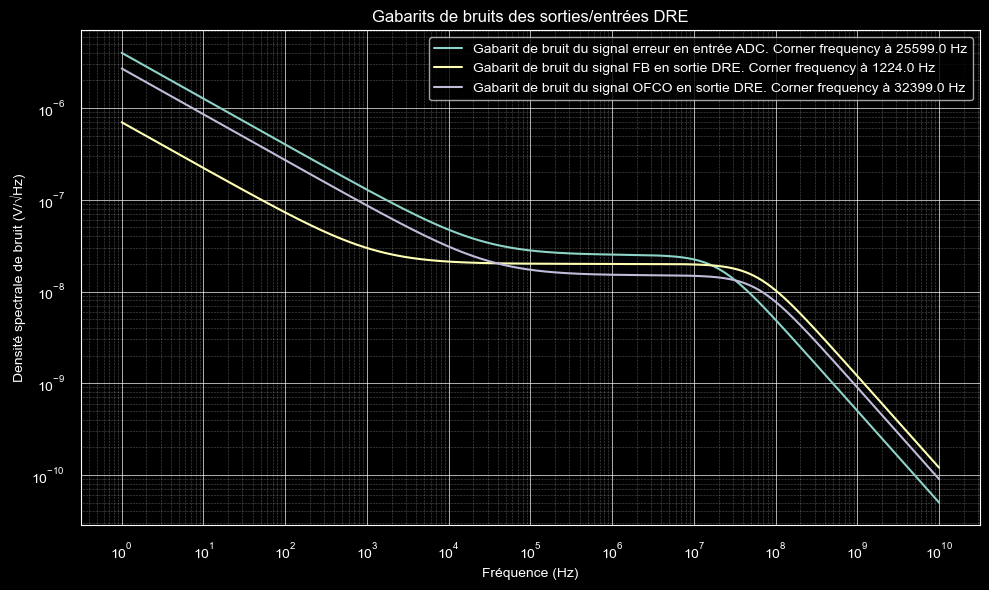

In [14]:
##### Tracé des différentes sources de bruit ####
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator

# --- Paramètres ---
f = np.logspace(0, 10, 1000)  # 1 Hz à 10 GHz
w = 2 * np.pi * f

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f, np.abs(e_error(w)),
          label=f"Gabarit de bruit du signal erreur en entrée ADC. Corner frequency à {fc_error:.1f} Hz")
ax.loglog(f, np.abs(e_mux(w)), label=f"Gabarit de bruit du signal FB en sortie DRE. Corner frequency à {fc_mux:.1f} Hz")
ax.loglog(f, np.abs(e_amp(w)),
          label=f"Gabarit de bruit du signal OFCO en sortie DRE. Corner frequency à {fc_amp:.1f} Hz")

### Mise en forme ###
ax.set_title("Gabarits de bruits des sorties/entrées DRE")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (V/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()

## Tracé en mode Dump (repliement)

Les sorties FB et OFCO sont rebouclées sur l'entrée erreur. L'ADC numérise les données en mode DUMP (125Msps)

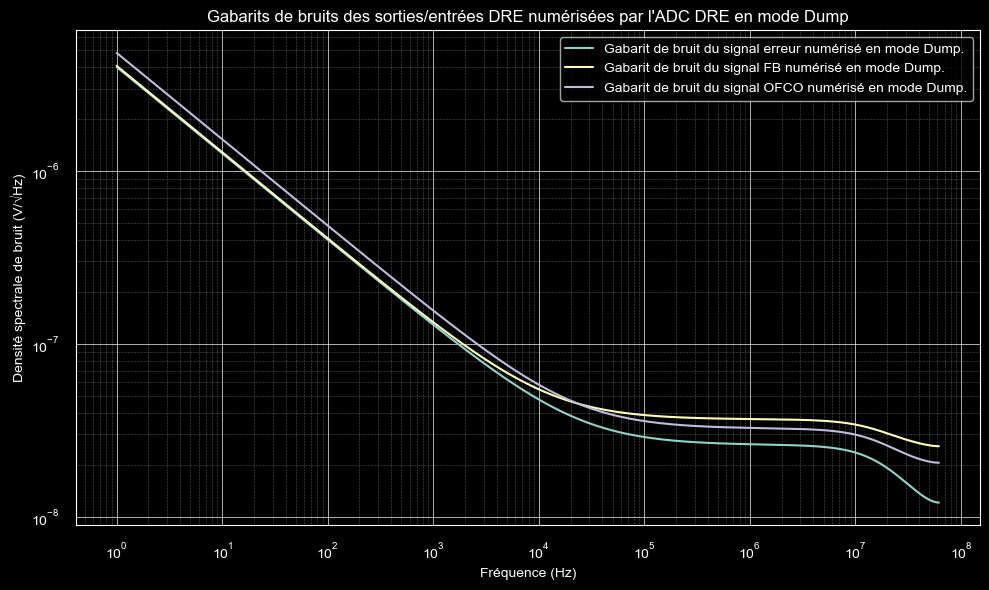

In [15]:
### Bruit replié par échantillonage ###

# ==== PARAMÈTRES ====
fmax = 100e9  # domaine fréquentiel du système analogique (Hz)
N_num = 1000  # nombre de points en numérique sur Fs/2
Fs = 125e6  #sample/s

#Ici on échantillonne par l'ADC. Cela implique un rebouclage des voies FB et OFCO sur la voie error
e_mux_error_real = lambda w: np.abs(np.sqrt(e_mux(w) ** 2 + e_error(w) ** 2))
e_amp_error_real = lambda w: np.abs(np.sqrt(e_amp(w) ** 2 + e_error(w) ** 2))
e_error_real = lambda w: np.abs(e_error(w))

f_num, e_error_fold = aliasing(e_error_real, fmax, Fs, N_num)
f_num, e_mux_error_fold = aliasing(e_mux_error_real, fmax, Fs, N_num)
f_num, e_amp_error_fold = aliasing(e_amp_error_real, fmax, Fs, N_num)

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f_num, np.abs(e_error_fold), label=f"Gabarit de bruit du signal erreur numérisé en mode Dump.")
ax.loglog(f_num, np.abs(e_mux_error_fold), label=f"Gabarit de bruit du signal FB numérisé en mode Dump.")
ax.loglog(f_num, np.abs(e_amp_error_fold), label=f"Gabarit de bruit du signal OFCO numérisé en mode Dump.")

### Mise en forme ###
ax.set_title("Gabarits de bruits des sorties/entrées DRE numérisées par l'ADC DRE en mode Dump")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (V/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()

In [16]:
export_2vectors_to_file(f_num, np.abs(e_error_fold), 'req-erro-only_Fref.txt')
export_2vectors_to_file(f_num, np.abs(e_mux_error_fold), 'req-erro-fdbk_Fref.txt')
export_2vectors_to_file(f_num, np.abs(e_amp_error_fold), 'req-erro-ofco_Fref.txt')


## Tracé en mode error

Les sorties FB et OFCO sont rebouclées sur l'entrée erreur. L'ADC numérise les données en mode ERROR (6.25Msps) sans moyenne.

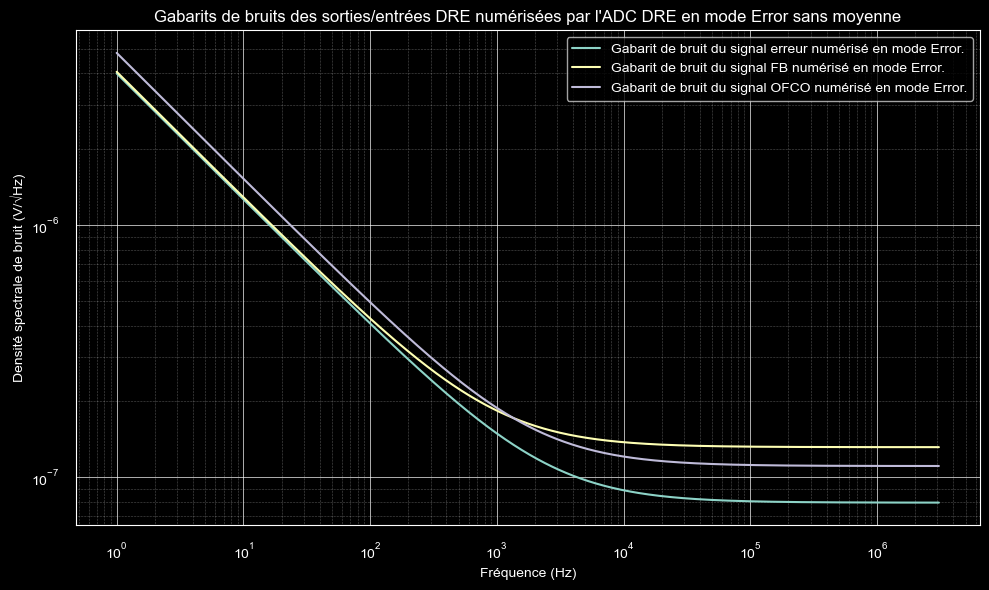

In [17]:
### Bruit replié par échantillonage ###

# ==== PARAMÈTRES ====
fmax = 100e9  # domaine fréquentiel du système analogique (Hz)
N_num = 1000  # nombre de points en numérique sur Fs/2
Fs = 6.25e6  #sample/s

#Ici on échantillonne par l'ADC. Cela implique un rebouclage des voies FB et OFCO sur la voie error
e_mux_error_real = lambda w: np.abs(np.sqrt(e_mux(w) ** 2 + e_error(w) ** 2))
e_amp_error_real = lambda w: np.abs(np.sqrt(e_amp(w) ** 2 + e_error(w) ** 2))
e_error_real = lambda w: np.abs(e_error(w))

f_num, e_error_fold = aliasing(e_error_real, fmax, Fs, N_num)
f_num, e_mux_error_fold = aliasing(e_mux_error_real, fmax, Fs, N_num)
f_num, e_amp_error_fold = aliasing(e_amp_error_real, fmax, Fs, N_num)

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(f_num, np.abs(e_error_fold), label=f"Gabarit de bruit du signal erreur numérisé en mode Error.")
ax.loglog(f_num, np.abs(e_mux_error_fold), label=f"Gabarit de bruit du signal FB numérisé en mode Error.")
ax.loglog(f_num, np.abs(e_amp_error_fold), label=f"Gabarit de bruit du signal OFCO numérisé en mode Error.")

### Mise en forme ###
ax.set_title("Gabarits de bruits des sorties/entrées DRE numérisées par l'ADC DRE en mode Error sans moyenne")
ax.set_xlabel("Fréquence (Hz)")
ax.set_ylabel("Densité spectrale de bruit (V/√Hz)")

# grille principale
ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
# grille secondaire (optionnelle, plus discrète)
ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)

# --- FORCER les graduations secondaires (minor ticks) ---
# Major ticks : puissances de 10 (10^n)
ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))

# Minor ticks : entre 2,3,...,9 * 10^n
# Utiliser subs = np.arange(2,10) (valeurs 2..9). Certains anciens matplotlib
# acceptent subs as list/tuple; ici on passe un ndarray.
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))

# Ajuster l'apparence des ticks
ax.tick_params(which='major', length=8, width=1)
ax.tick_params(which='minor', length=4, width=0.8, color='gray')

ax.legend()
plt.tight_layout()
plt.show()

In [18]:
export_2vectors_to_file(f_num, np.abs(e_error_fold), 'req-erro-only_Frow.txt')
export_2vectors_to_file(f_num, np.abs(e_mux_error_fold), 'req-erro-fdbk_Frow.txt')
export_2vectors_to_file(f_num, np.abs(e_amp_error_fold), 'req-erro-ofco_Frow.txt')
